In [6]:
# import library
import pandas as pd

In [7]:
# import dataset
file_path = "Group 8- original dataset-Electronic_sales_Sep2023-Sep2024.csv"
sale_data = pd.read_csv(file_path)

In [8]:
# data preprocessing & cleaning
# step 1:transfer date form
sale_data["Purchase Date"] = pd.to_datetime(sale_data["Purchase Date"], errors="coerce")

# step 2:delete "cancelled" orders
#boolean indexing, filtering completed orders only
is_completed = sale_data["Order Status"] == "Completed"

# apply the filter
sales_cleaned = sale_data[is_completed].copy()

#step 3:replacing the mode to "N/A" cell in gender field
#we use [0] to get the actual value, as .mode() returns pandas series
gender_mode= sales_cleaned["Gender"].mode()[0]

sales_cleaned["Gender"]= sales_cleaned["Gender"].replace("#N/A",gender_mode).fillna(gender_mode)

#new cleaned data csv
output_file_path = 'sales_data_FINAL_CLEANED.csv'
sales_cleaned.to_csv(output_file_path, index=False) # index=False prevents writing the DataFrame index as a column

In [9]:
# create a new set to caculate
rfm_data = []

# get the unique customer id
customers = sales_cleaned["Customer ID"].unique()

# calculate each customer's R, F, M; identify the calculation formulas as below:
## R = last snapshot_date - last purchase date, while snapshot date was defined later;
## F = purchase times (count customer ID);
## M = total purchase cost (sum of total price of each customer).

#set a snapshot date = the last date of purchase(all customers) + 1
snapshot_date = sales_cleaned["Purchase Date"].max() + pd.Timedelta(days=1)

for cid in customers:
    customer_data = sales_cleaned[sales_cleaned["Customer ID"] == cid]
    
    # calculate R
    first_date = customer_data["Purchase Date"].min()
    last_date = customer_data["Purchase Date"].max()
    R = (snapshot_date - last_date).days

    # calculate F
    F = len(customer_data)
    
    # calculate M
    M = customer_data["Total Price"].sum()
        
    # calculate lisespan (for later customer score)
    lifespan = (last_date - first_date).days + 1
    # calculate average_purchase_value (for later customer score)
    average_purchase_value = M / customer_data["Customer ID"].count()
    
    # put the results into rfm_data
    rfm_data.append([cid, R, F, M, lifespan, average_purchase_value])

In [10]:
# transfer to pandas DataFrame
customer_analysis = pd.DataFrame(rfm_data, columns=["Customer ID", "R", "F", "M", "lifespan", "average_purchase_value"])

# set score methods for R, F, M, the rules are identified as below (compare each single customer with population):
## if R_single < average R_population, assign it with 1, otherwise assign with 0;
## if F_single > average F_population, assign it with 1, otherwise assign with 0;
## if M_single > median M_population, assign it with 1, otherwise assign with 0:
### the reason why we choose median_M instead of average_M is for better and more significant categorizing

# calculate the average/median threshold
R_mean = customer_analysis["R"].mean()
F_mean = customer_analysis["F"].mean()
M_median = customer_analysis["M"].median()

# score for each customer
R_score_list = []
F_score_list = []
M_score_list = []
RFM_value_list = []

for i in range(len(customer_analysis)):
    r = customer_analysis.loc[i, "R"]
    f = customer_analysis.loc[i, "F"]
    m = customer_analysis.loc[i, "M"]
    
    # score R
    if r < R_mean:
        R_score = 1
    else:
        R_score = 0
    
    # score F
    if f > F_mean:
        F_score = 1
    else:
        F_score = 0
    
    # socre M
    if m > M_median:
        M_score = 1
    else:
        M_score = 0
    
    # joint R, F, M
    RFM_value = str(R_score) + str(F_score) + str(M_score)
    
    # store the results
    R_score_list.append(R_score)
    F_score_list.append(F_score)
    M_score_list.append(M_score)
    RFM_value_list.append(RFM_value)

# add results to final dataset
customer_analysis["R_score"] = R_score_list
customer_analysis["F_score"] = F_score_list
customer_analysis["M_score"] = M_score_list
customer_analysis["RFM_value"] = RFM_value_list

print(customer_analysis.head())

   Customer ID    R  F         M  lifespan  average_purchase_value  R_score  \
0         1000  157  1    741.09         1                 741.090        0   
1         1002   46  2   5020.60       298                2510.300        1   
2         1003  126  1     41.50         1                  41.500        1   
3         1004  121  1     83.00         1                  83.000        1   
4         1005   92  2  11779.11       147                5889.555        1   

   F_score  M_score RFM_value  
0        0        0       000  
1        1        1       111  
2        0        0       100  
3        0        0       100  
4        1        1       111  


In [11]:
# add Customer Bucket and Precise Marketing for different RFM value customers

# set the strategy map and rules 
rfm_strategy_map = {
    '111': ('Champion', 'Give special rewards and priority access to new products.'),
    '110': ('Loyal customer', 'Increase engagement with exclusive offers by conducting personal email campaigns and referral programs.'),
    '101': ('Potential Loyalist', 'Convert them into loyal customers by providing discounts on second purchases.'),
    '100': ('Promising', 'Encourage them to increase purchases through special promos for second purchases, upselling and cross-selling.'),
    '011': ('Needs Attention', 'Bring back their interest by sending limited-time offers.'),
    '010': ('Needs Attention', 'Bring back their interest by sending limited-time offers.'),
    '001': ('At Risk', 'Identify the reasons they stop shopping with satisfaction surveys and return special offers.'),
    '000': ('Can’t Lose Them', 'Reactivate with attractive offers by carrying out big discounts, bundling offers, and reminder campaigns via email.')
}

#add to csutomer_analysis
customer_analysis['Customer Bucket'] = (
    customer_analysis['RFM_value']
    .astype(str)
    .map(lambda x: rfm_strategy_map.get(x, ('Unknown', 'No recommendation'))[0])
)
customer_analysis['Precise Marketing'] = (
    customer_analysis['RFM_value']
    .astype(str)
    .map(lambda x: rfm_strategy_map.get(x, ('Unknown', 'No recommendation'))[1])
)


In [13]:
# customer score
# we want to socre customers based on thier shopping behaviours, higher socre, better customer

customer_score_list = []

for i in range(len(customer_analysis)):
    lifespan = customer_analysis.loc[i, "lifespan"]
    frequency = customer_analysis.loc[i, "F"]
    average_purchase_value = customer_analysis.loc[i, "average_purchase_value"]
    
    #calculate customer score
    customer_score = lifespan * frequency * average_purchase_value
    # store the results
    customer_score_list.append(customer_score)
    
# add results to final dataset
customer_analysis["customer_score"] = customer_score_list

In [14]:
customer_analysis.head()

,Customer ID,R,F,M,lifespan,average_purchase_value,R_score,F_score,M_score,RFM_value,Customer Bucket,Precise Marketing,customer_score
0,1000,157,1,741.09,1,741.090,0,0,0,000,Can’t Lose Them,Reactivate with attractive offers by carrying ...,741.09
1,1002,46,2,5020.60,298,2510.300,1,1,1,111,Champion,Give special rewards and priority access to ne...,1496138.80
2,1003,126,1,41.50,1,41.500,1,0,0,100,Promising,Encourage them to increase purchases through s...,41.50
3,1004,121,1,83.00,1,83.000,1,0,0,100,Promising,Encourage them to increase purchases through s...,83.00
4,1005,92,2,11779.11,147,5889.555,1,1,1,111,Champion,Give special rewards and priority access to ne...,1731529.17


In [17]:
# identify the final customer membership type of each customer
# Types of memership: New / Regular / Churned / Non
# 1. New Member      → A customer who was previously not a member ("No") 
#                       but later became a member ("Yes").
#
# 2. Regular Member  → A customer who is consistently a member ("Yes")
#                       across their purchase history.
#
# 3. Churned Member  → A customer who used to be a member ("Yes") 
#                       but later stopped being a member ("No").
#
# 4. Non Member      → A customer who never joined the membership program
#                       ("No" in all purchase records) or has no membership data.

#set purchase date
sale_data['Purchase Date'] = pd.to_datetime(sale_data['Purchase Date'])
df_sorted = sale_data.sort_values(['Customer ID', 'Purchase Date'])

#set a list to identify and store customer membership type during traversals
membership_records = []

# identify changes of each customer
for customer_id, group in df_sorted.groupby('Customer ID'):
    previous_status = None
    last_type = 'Non Member'  # set "Non Member" as original status
    
    for _, row in group.iterrows():
        current_status = row['Loyalty Member']
        
        if previous_status is None:
            if current_status == 'Yes':
                last_type = 'Regular Member'
            else:
                last_type = 'Non Member'
        else:
            if previous_status == 'Yes' and current_status == 'No':
                last_type = 'Churned'
            elif previous_status == 'No' and current_status == 'Yes':
                last_type = 'New Member'
            elif current_status == 'Yes':
                last_type = 'Regular Member'
            else:
                last_type = 'Non Member'
        previous_status = current_status

    membership_records.append({'Customer ID': customer_id, 'Membership Type': last_type})

# transfer the final status to DataFrame
membership_df = pd.DataFrame(membership_records)

# add to customer_analysis
customer_analysis = customer_analysis.merge(membership_df, on='Customer ID', how='left')

# input "Non Member" to customers with no membership data
customer_analysis['Membership Type'] = customer_analysis['Membership Type'].fillna('Non Member')

In [18]:
customer_analysis.head()

,Customer ID,R,F,M,lifespan,average_purchase_value,R_score,F_score,M_score,RFM_value,Customer Bucket,Precise Marketing,customer_score,Membership Type
0,1000,157,1,741.09,1,741.090,0,0,0,000,Can’t Lose Them,Reactivate with attractive offers by carrying ...,741.09,Non Member
1,1002,46,2,5020.60,298,2510.300,1,1,1,111,Champion,Give special rewards and priority access to ne...,1496138.80,New Member
2,1003,126,1,41.50,1,41.500,1,0,0,100,Promising,Encourage them to increase purchases through s...,41.50,Regular Member
3,1004,121,1,83.00,1,83.000,1,0,0,100,Promising,Encourage them to increase purchases through s...,83.00,Non Member
4,1005,92,2,11779.11,147,5889.555,1,1,1,111,Champion,Give special rewards and priority access to ne...,1731529.17,Non Member


  Membership Type  Number of Customers
0      Non Member                 6573
1  Regular Member                 1160
2         Churned                  898
3      New Member                  835


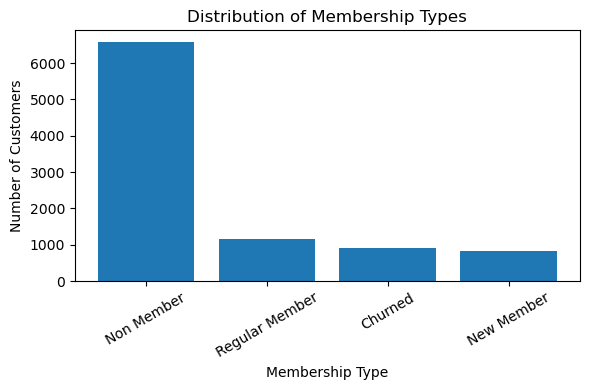

In [22]:
membership_counts = customer_analysis['Membership Type'].value_counts().reset_index()
membership_counts.columns = ['Membership Type', 'Number of Customers']

# Display the summary table
print(membership_counts)

# visualiz
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(membership_counts['Membership Type'], membership_counts['Number of Customers'])
plt.title('Distribution of Membership Types')
plt.xlabel('Membership Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()